# Phase 3: Risk Effects (Log-Linear and Non-Log-Linear)

Phase 3 attaches two flavors of risk effect to the disease
transition rates:

**Log-linear** (`RiskEffectWithoutPAF`): the GBD 2023 USA artifact
stores BMI relative risks as log-linear "per unit" values
affecting two heart-failure causes:

- `heart_failure_from_ischemic_heart_disease.incidence_rate`
- `heart_failure_residual.incidence_rate`

**Non-log-linear** (`NonLogLinearRiskEffectWithoutPAF`): the
artifact stores SBP relative risks as a 200,000-row long-form
table with 1000 distinct exposure-level `parameter` values and a
monotonically rising RR. vph 5's `NonLogLinearRiskEffect` reads
that table directly, builds piecewise-linear interpolation
intervals, anchors them on the TMRED-sampled TMREL, and looks up
each simulant's RR from their cached SBP exposure. This notebook
demonstrates the `SBP -> acute_ischemic_stroke.incidence_rate`
effect.

The model spec used here is
`src/vivarium_nih_us_cvd/model_specifications/nih_us_cvd_phase3.yaml`.
It is Phase 2 plus three risk-effect declarations from the
project's own `effects.py`.

What this notebook checks:

1. The `RiskEffectWithoutPAF` subclass loads its log-linear RR
   table cleanly even though the artifact tags the rows with a
   single-value `parameter='per unit'` index level.
2. The `NonLogLinearRiskEffectWithoutPAF` subclass loads the
   exposure-indexed RR table for SBP and registers the cached
   exposure column needed for interval lookup.
3. The relative-risk pipelines `<risk>_on_<target>.relative_risk`
   are registered and produce reasonable per-simulant values.
4. **Log-linear**: BMI -> HF RR is monotone in exposure with the
   characteristic flat tail at RR = 1 below TMREL.
5. **Non-log-linear**: SBP -> AIS RR is monotone in exposure and
   tracks the artifact's tabulated dose-response curve (rising
   from 1.0 at TMREL up to >10x at high SBP).
6. The downstream `<target>.incidence_rate` pipeline reflects the
   RR adjustment (compared against the unmodified base rate from
   Phase 2 / artifact data).
7. Stepping the simulation does not crash.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vivarium import InteractiveContext

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

PHASE2_SPEC = '../src/vivarium_nih_us_cvd/model_specifications/nih_us_cvd_phase2.yaml'
PHASE3_SPEC = '../src/vivarium_nih_us_cvd/model_specifications/nih_us_cvd_phase3.yaml'

HF_TARGETS = [
    'heart_failure_from_ischemic_heart_disease',
    'heart_failure_residual',
]
RR_PIPELINES = [
    f'high_body_mass_index_in_adults_on_{t}.relative_risk' for t in HF_TARGETS
]
RATE_PIPELINES = [f'{t}.incidence_rate' for t in HF_TARGETS]

# Non-log-linear effect: SBP -> acute ischemic stroke
SBP_EXPOSURE = 'high_systolic_blood_pressure.exposure'
SBP_RR_PIPELINE = 'high_systolic_blood_pressure_on_acute_ischemic_stroke.relative_risk'
AIS_RATE_PIPELINE = 'acute_ischemic_stroke.incidence_rate'


## 1. Set up the simulation

If `InteractiveContext(...)` returns without raising, the new
`RiskEffectWithoutPAF` components have:

- loaded the `risk_factor.high_body_mass_index_in_adults.relative_risk`
  table from the artifact (250-draw long form),
- stripped the single-value `parameter='per unit'` index level
  before binning,
- registered the relative-risk value pipelines, and
- registered a target rate modifier on each heart-failure
  incidence rate.


In [2]:
sim = InteractiveContext(PHASE3_SPEC)
print('setup OK')
print('current time:', sim.current_time)


2026-04-11 09:52:58.812 | INFO     | simulation_1-artifact_manager:80 - Running simulation from artifact located at /home/abie/vivarium_nih_us_cvd/src/vivarium_nih_us_cvd/artifacts/united_states_of_america.hdf.


2026-04-11 09:52:58.813 | INFO     | simulation_1-artifact_manager:81 - Artifact base filter terms are [].


2026-04-11 09:52:58.814 | INFO     | simulation_1-artifact_manager:82 - Artifact additional filter terms are None.


2026-04-11 09:53:28.130 | WARNING  | simulation_1-lookup_table_manager:85 - Component 'susceptible_state.susceptible_to_ischemic_stroke' configured, but didn't build lookup table 'initialization_weights' during setup.


2026-04-11 09:53:28.131 | WARNING  | simulation_1-lookup_table_manager:85 - Component 'disease_state.acute_ischemic_stroke' configured, but didn't build lookup table 'initialization_weights' during setup.


...

2026-04-11 09:53:28.142 | WARNING  | simulation_1-lookup_table_manager:85 - Component 'risk_factor.high_fasting_plasma_glucose' configured, but didn't build lookup table 'exposure' during setup.


2026-04-11 09:53:28.143 | WARNING  | simulation_1-lookup_table_manager:85 - Component 'risk_factor.high_fasting_plasma_glucose' configured, but didn't build lookup table 'ensemble_distribution_weights' during setup.


2026-04-11 09:53:28.143 | WARNING  | simulation_1-lookup_table_manager:85 - Component 'risk_factor.high_fasting_plasma_glucose' configured, but didn't build lookup table 'exposure_standard_deviation' during setup.


2026-04-11 09:53:28.144 | INFO     | simulation_1-results_context:131 - The following stratifications are registered but not used by any observers: 
['event_year']


setup OK
current time: 2024-01-01 00:00:00


## 2. Find the new pipelines

The relative-risk pipelines should appear under
`<risk>_on_<target>.relative_risk`.


In [3]:
attrs = sim.get_attribute_names()
new_pipes = [a for a in sorted(attrs) if 'on_heart_failure' in a]
for a in new_pipes:
    print(' ', a)


  high_body_mass_index_in_adults_on_heart_failure_from_ischemic_heart_disease.relative_risk
  high_body_mass_index_in_adults_on_heart_failure_residual.relative_risk


## 3. Pull the population view

We grab BMI exposure, both relative-risk pipelines, and both
heart-failure incidence-rate pipelines for the simulants.


In [4]:
ATTRS = ['age', 'sex', 'is_alive']
ATTRS += ['high_body_mass_index_in_adults.exposure']
ATTRS += [SBP_EXPOSURE]
ATTRS += RR_PIPELINES
ATTRS += [SBP_RR_PIPELINE]
ATTRS += RATE_PIPELINES
ATTRS += [AIS_RATE_PIPELINE]

pop = sim.get_population(ATTRS)
adults = pop[pop['age'] >= 25].copy()
print(f'{len(adults)} adults out of {len(pop)} simulants')
print()
print(adults.head())


2026-04-11 09:53:28.947 | WARNING  | simulation_1-population_manager:747 - The 'acute_ischemic_stroke.incidence_rate.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'acute_ischemic_stroke.incidence_rate.paf'.


2026-04-11 09:53:29.119 | WARNING  | simulation_1-population_manager:747 - The 'heart_failure_from_ischemic_heart_disease.incidence_rate.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'heart_failure_from_ischemic_heart_disease.incidence_rate.paf'.


2026-04-11 09:53:29.273 | WARNING  | simulation_1-population_manager:747 - The 'heart_failure_residual.incidence_rate.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'heart_failure_residual.incidence_rate.paf'.


726 adults out of 1000 simulants

         age     sex  is_alive  high_body_mass_index_in_adults.exposure  high_systolic_blood_pressure.exposure  \
0  52.886352  Female      True                                29.763196                             122.300801   
1  81.557394  Female      True                                17.206446                             141.535996   
2  71.985765    Male      True                                33.082305                             142.555967   
3  47.572942    Male      True                                27.101684                             130.688714   
4  54.727528    Male      True                                41.708621                             141.457920   

   high_body_mass_index_in_adults_on_heart_failure_from_ischemic_heart_disease.relative_risk  high_body_mass_index_in_adults_on_heart_failure_residual.relative_risk  \
0                                           1.239166                                                             

## 4. Relative risk distribution

A log-linear `per unit` BMI effect predicts
`RR_i = exp(beta * (bmi_i - tmrel))` for `bmi_i > tmrel` and
`RR_i = 1` otherwise. So we expect a degenerate-at-1 lower bound
(simulants below TMREL) and a long right tail.


In [5]:
print('BMI->HF_IHD relative risk:')
print(adults[RR_PIPELINES[0]].describe().round(3))
print()
print('BMI->HF_residual relative risk:')
print(adults[RR_PIPELINES[1]].describe().round(3))


BMI->HF_IHD relative risk:
count    726.000
mean       1.280
std        0.250
min        1.000
25%        1.104
50%        1.233
75%        1.393
max        3.249
Name: high_body_mass_index_in_adults_on_heart_failure_from_ischemic_heart_disease.relative_risk, dtype: float64

BMI->HF_residual relative risk:
count    726.000
mean       1.280
std        0.250
min        1.000
25%        1.104
50%        1.233
75%        1.393
max        3.249
Name: high_body_mass_index_in_adults_on_heart_failure_residual.relative_risk, dtype: float64


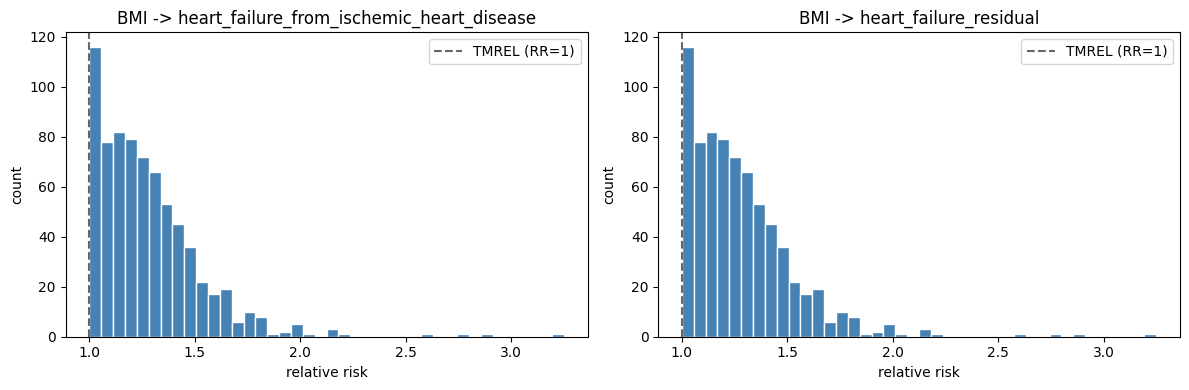

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, target, pipe in zip(axes, HF_TARGETS, RR_PIPELINES):
    ax.hist(adults[pipe], bins=40, color='steelblue', edgecolor='white')
    ax.axvline(1.0, color='k', linestyle='--', alpha=0.6, label='TMREL (RR=1)')
    ax.set_title(f'BMI -> {target}')
    ax.set_xlabel('relative risk')
    ax.set_ylabel('count')
    ax.legend()
plt.tight_layout()
plt.show()


## 5. Relative risk vs. BMI exposure

For a log-linear effect we should see a clean monotone relationship
between BMI exposure and the per-simulant relative risk: flat at
RR = 1 below the TMREL anchor and rising above it.


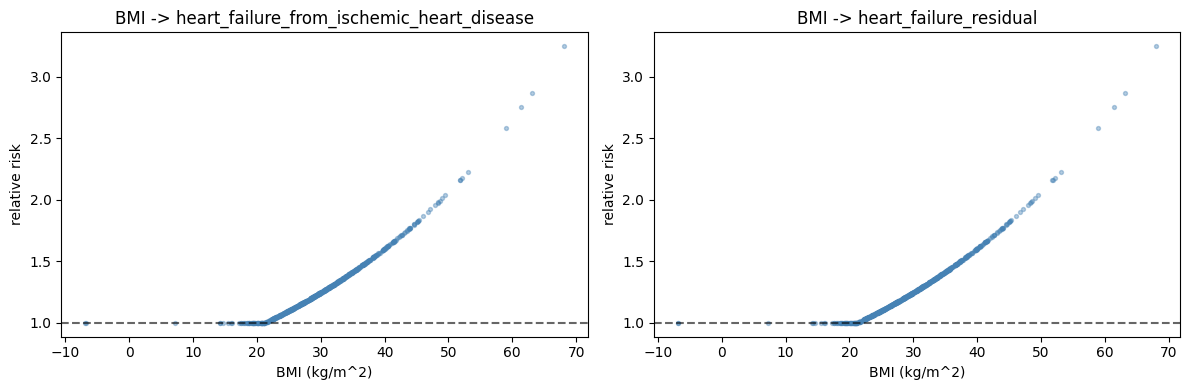

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, target, pipe in zip(axes, HF_TARGETS, RR_PIPELINES):
    ax.scatter(
        adults['high_body_mass_index_in_adults.exposure'],
        adults[pipe],
        s=8, alpha=0.4, color='steelblue',
    )
    ax.axhline(1.0, color='k', linestyle='--', alpha=0.6)
    ax.set_title(f'BMI -> {target}')
    ax.set_xlabel('BMI (kg/m^2)')
    ax.set_ylabel('relative risk')
plt.tight_layout()
plt.show()


## 6. Cross-check vs. Phase 2 (no risk effect)

Phase 2 has the same disease and risk components but no
`RiskEffectWithoutPAF`. The heart-failure incidence rates pulled
from Phase 2 should equal the artifact baseline. The Phase 3 rates
should equal `baseline * RR` (with the same simulants since both
specs use seed 0 and identical population settings).


In [8]:
sim2 = InteractiveContext(PHASE2_SPEC)
ATTRS2 = (
    ['age', 'sex', 'is_alive',
     'high_body_mass_index_in_adults.exposure',
     SBP_EXPOSURE]
    + RATE_PIPELINES
    + [AIS_RATE_PIPELINE]
)
pop2 = sim2.get_population(ATTRS2)
adults2 = pop2[pop2['age'] >= 25].copy()
print(f'phase2 adults: {len(adults2)}')
print()
print('phase2 baseline HF_IHD incidence rate:')
print(adults2[RATE_PIPELINES[0]].describe())
print()
print('phase2 baseline AIS incidence rate:')
print(adults2[AIS_RATE_PIPELINE].describe())


2026-04-11 09:53:30.141 | INFO     | simulation_2-artifact_manager:80 - Running simulation from artifact located at /home/abie/vivarium_nih_us_cvd/src/vivarium_nih_us_cvd/artifacts/united_states_of_america.hdf.


2026-04-11 09:53:30.141 | INFO     | simulation_2-artifact_manager:81 - Artifact base filter terms are [].


2026-04-11 09:53:30.142 | INFO     | simulation_2-artifact_manager:82 - Artifact additional filter terms are None.


2026-04-11 09:53:35.096 | WARNING  | simulation_2-lookup_table_manager:85 - Component 'susceptible_state.susceptible_to_ischemic_stroke' configured, but didn't build lookup table 'initialization_weights' during setup.


2026-04-11 09:53:35.096 | WARNING  | simulation_2-lookup_table_manager:85 - Component 'disease_state.acute_ischemic_stroke' configured, but didn't build lookup table 'initialization_weights' during setup.


...

2026-04-11 09:53:35.107 | INFO     | simulation_2-results_context:131 - The following stratifications are registered but not used by any observers: 
['event_year']


2026-04-11 09:53:35.642 | WARNING  | simulation_2-population_manager:747 - The 'acute_ischemic_stroke.incidence_rate.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'acute_ischemic_stroke.incidence_rate.paf'.


2026-04-11 09:53:35.790 | WARNING  | simulation_2-population_manager:747 - The 'heart_failure_from_ischemic_heart_disease.incidence_rate.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'heart_failure_from_ischemic_heart_disease.incidence_rate.paf'.


2026-04-11 09:53:35.802 | WARNING  | simulation_2-population_manager:747 - The 'heart_failure_residual.incidence_rate.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'heart_failure_residual.incidence_rate.paf'.


phase2 adults: 726

phase2 baseline HF_IHD incidence rate:
count    726.000000
mean       0.000437
std        0.001030
min        0.000003
25%        0.000009
50%        0.000045
75%        0.000422
max        0.011078
Name: heart_failure_from_ischemic_heart_disease.incidence_rate, dtype: float64

phase2 baseline AIS incidence rate:
count    726.000000
mean       0.000142
std        0.000181
min        0.000011
25%        0.000021
50%        0.000060
75%        0.000200
max        0.001118
Name: acute_ischemic_stroke.incidence_rate, dtype: float64


In [9]:
common = adults.index.intersection(adults2.index)
print(f'{len(common)} simulants present in both phases')
print()
ratios = pd.DataFrame(index=common)
for target, pipe in zip(HF_TARGETS, RATE_PIPELINES):
    base = adults2.loc[common, pipe]
    boosted = adults.loc[common, pipe]
    nonzero = base > 0
    ratios[target] = np.nan
    ratios.loc[nonzero, target] = boosted[nonzero] / base[nonzero]

# Compare ratio (phase3 rate / phase2 rate) to the relative-risk pipeline.
for target, rr_pipe in zip(HF_TARGETS, RR_PIPELINES):
    rr = adults.loc[common, rr_pipe]
    ratio = ratios[target]
    diff = (ratio - rr).abs()
    print(f'{target}: max |rate_ratio - RR| = {diff.max():.6f}, '
          f'mean = {diff.mean():.6f}')


726 simulants present in both phases

heart_failure_from_ischemic_heart_disease: max |rate_ratio - RR| = 0.000000, mean = 0.000000
heart_failure_residual: max |rate_ratio - RR| = 0.000000, mean = 0.000000


If the max absolute difference is essentially zero, the risk
effect is being applied multiplicatively as expected.


## 7. Non-log-linear effect: SBP -> acute ischemic stroke

The next section exercises the **non-log-linear** branch:
`NonLogLinearRiskEffectWithoutPAF` reads the artifact's
exposure-indexed RR table for SBP and looks up each simulant's RR
based on their cached SBP exposure (using piecewise-linear
interpolation between the tabulated parameter values, anchored on
the TMRED-sampled TMREL).

Unlike the log-linear case, the dose-response curve is not a
simple `exp(beta * delta)` — it follows whatever shape the GBD
relative risk surface has. We expect:

- RR = 1 at SBP at or below the TMREL anchor (~110-115 mmHg).
- A monotone, accelerating rise as SBP increases.
- Mean RR by SBP bin should match the artifact's tabulated curve,
  reaching values above 10x for SBP in the 200+ range.


In [10]:
print('SBP -> AIS relative risk:')
print(adults[SBP_RR_PIPELINE].describe().round(3))
print()
print('SBP exposure:')
print(adults[SBP_EXPOSURE].describe().round(2))


SBP -> AIS relative risk:
count    726.000
mean       2.317
std        1.705
min        1.000
25%        1.179
50%        1.763
75%        2.862
max       14.623
Name: high_systolic_blood_pressure_on_acute_ischemic_stroke.relative_risk, dtype: float64

SBP exposure:
count    726.00
mean     124.27
std       18.23
min       42.88
25%      112.58
50%      122.30
75%      134.44
max      203.75
Name: high_systolic_blood_pressure.exposure, dtype: float64


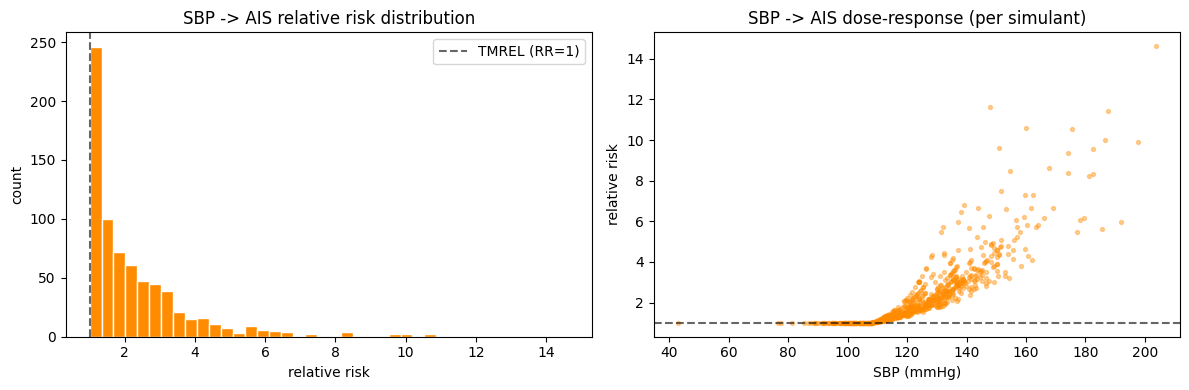

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of RR values
axes[0].hist(adults[SBP_RR_PIPELINE], bins=40,
             color='darkorange', edgecolor='white')
axes[0].axvline(1.0, color='k', linestyle='--', alpha=0.6,
                label='TMREL (RR=1)')
axes[0].set_title('SBP -> AIS relative risk distribution')
axes[0].set_xlabel('relative risk')
axes[0].set_ylabel('count')
axes[0].legend()

# Scatter: RR vs SBP exposure
axes[1].scatter(
    adults[SBP_EXPOSURE],
    adults[SBP_RR_PIPELINE],
    s=8, alpha=0.4, color='darkorange',
)
axes[1].axhline(1.0, color='k', linestyle='--', alpha=0.6)
axes[1].set_title('SBP -> AIS dose-response (per simulant)')
axes[1].set_xlabel('SBP (mmHg)')
axes[1].set_ylabel('relative risk')
plt.tight_layout()
plt.show()


### 7a. Mean RR by SBP bin

Bin simulants by SBP exposure in 10 mmHg increments and look at
the mean RR per bin. This is the cleanest view of the underlying
dose-response curve — it should rise smoothly from 1.0 at the
TMREL anchor up to >10x at high SBP.


In [12]:
sbp = adults[SBP_EXPOSURE]
rr = adults[SBP_RR_PIPELINE]

bins = np.arange(70, 220, 10)
bin_labels = pd.cut(sbp, bins=bins)
dose_response = (
    pd.DataFrame({'sbp_bin': bin_labels, 'rr': rr})
    .groupby('sbp_bin', observed=True)['rr']
    .agg(['mean', 'min', 'max', 'count'])
    .round(3)
)
print(dose_response)


              mean     min     max  count
sbp_bin                                  
(70, 80]     1.000   1.000   1.000      2
(80, 90]     1.000   1.000   1.000      8
(90, 100]    1.000   1.000   1.000     34
(100, 110]   1.010   1.000   1.084     98
(110, 120]   1.341   1.066   2.219    171
(120, 130]   2.031   1.362   4.348    164
(130, 140]   2.903   1.763   6.799    130
(140, 150]   3.925   2.357  11.605     60
(150, 160]   5.200   3.214  10.600     33
(160, 170]   6.122   4.118   8.626     10
(170, 180]   7.680   5.498  10.563      6
(180, 190]   8.863   5.619  11.412      6
(190, 200]   7.917   5.951   9.883      2
(200, 210]  14.623  14.623  14.623      1


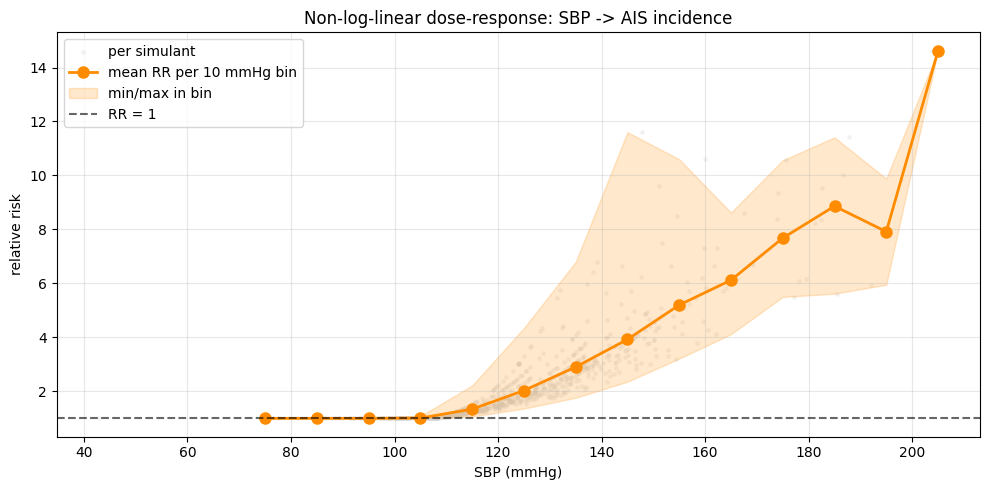

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

# Per-simulant scatter (background)
ax.scatter(sbp, rr, s=6, alpha=0.2, color='lightgray',
           label='per simulant')

# Mean RR by SBP bin (foreground)
bin_centers = [interval.mid for interval in dose_response.index]
ax.plot(bin_centers, dose_response['mean'], 'o-',
        color='darkorange', linewidth=2, markersize=8,
        label='mean RR per 10 mmHg bin')
ax.fill_between(
    bin_centers,
    dose_response['min'],
    dose_response['max'],
    alpha=0.2, color='darkorange',
    label='min/max in bin',
)

ax.axhline(1.0, color='k', linestyle='--', alpha=0.6,
           label='RR = 1')
ax.set_title('Non-log-linear dose-response: SBP -> AIS incidence')
ax.set_xlabel('SBP (mmHg)')
ax.set_ylabel('relative risk')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 7b. Cross-check vs Phase 2 for AIS

Same multiplicative-application check as we did for the log-linear
BMI effect: the Phase 3 AIS incidence rate should equal the Phase 2
baseline AIS rate times the SBP-on-AIS RR pipeline value, simulant
by simulant.


In [14]:
common = adults.index.intersection(adults2.index)
base_ais = adults2.loc[common, AIS_RATE_PIPELINE]
boosted_ais = adults.loc[common, AIS_RATE_PIPELINE]
sbp_rr = adults.loc[common, SBP_RR_PIPELINE]

nonzero = base_ais > 0
ratio = boosted_ais[nonzero] / base_ais[nonzero]
diff = (ratio - sbp_rr[nonzero]).abs()
print(f'AIS: max |rate_ratio - RR| = {diff.max():.6f}, '
      f'mean = {diff.mean():.6f}')
print()
print('phase2 AIS rate (baseline):')
print(base_ais.describe().round(6))
print()
print('phase3 AIS rate (with SBP effect):')
print(boosted_ais.describe().round(6))


AIS: max |rate_ratio - RR| = 0.000000, mean = 0.000000

phase2 AIS rate (baseline):


count    726.000000
mean       0.000142
std        0.000181
min        0.000011
25%        0.000021
50%        0.000060
75%        0.000200
max        0.001118
Name: acute_ischemic_stroke.incidence_rate, dtype: float64

phase3 AIS rate (with SBP effect):
count    726.000000
mean       0.000363
std        0.000597
min        0.000011
25%        0.000040
50%        0.000131
75%        0.000403
max        0.005376
Name: acute_ischemic_stroke.incidence_rate, dtype: float64


## 8. Step the simulation forward

Run for one simulated year and confirm the disease state machines
still fire (a regression check on top of Phases 1 and 2).


In [15]:
for _ in range(13):  # ~1 year
    sim.step()
print('current time:', sim.current_time)

pop_after = sim.get_population(ATTRS)
print('alive after 1y:', int(pop_after['is_alive'].sum()), '/', len(pop_after))


2026-04-11 09:53:36.302 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2024-01-01 00:00:00


2026-04-11 09:53:36.502 | WARNING  | simulation_1-population_manager:747 - The 'affected_unmodeled.cause_specific_mortality_rate.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'affected_unmodeled.cause_specific_mortality_rate.paf'.


2026-04-11 09:53:36.510 | WARNING  | simulation_1-population_manager:747 - The 'acute_ischemic_stroke.excess_mortality_rate.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'acute_ischemic_stroke.excess_mortality_rate.paf'.


2026-04-11 09:53:36.528 | WARNING  | simulation_1-population_manager:747 - The 'chronic_ischemic_stroke.excess_mortality_rate.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'chronic_ischemic_stroke.excess_mortality_rate.paf'.


2026-04-11 09:53:36.541 | WARNING  | simulation_1-population_manager:747 - The 'acute_myocardial_infarction.excess_mortality_rate.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'acute_myocardial_infarction.excess_mortality_rate.paf'.


...

current time: 2024-12-30 00:00:00


2026-04-11 09:53:47.045 | WARNING  | simulation_1-population_manager:747 - The 'acute_ischemic_stroke.incidence_rate.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'acute_ischemic_stroke.incidence_rate.paf'.


2026-04-11 09:53:47.221 | WARNING  | simulation_1-population_manager:747 - The 'heart_failure_from_ischemic_heart_disease.incidence_rate.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'heart_failure_from_ischemic_heart_disease.incidence_rate.paf'.


2026-04-11 09:53:47.379 | WARNING  | simulation_1-population_manager:747 - The 'heart_failure_residual.incidence_rate.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'heart_failure_residual.incidence_rate.paf'.


alive after 1y: 990 / 1000


In [16]:
adults_after = pop_after[pop_after['age'] >= 25].copy()
print('BMI->HF_IHD RR (after 1y):')
print(adults_after[RR_PIPELINES[0]].describe().round(3))


BMI->HF_IHD RR (after 1y):
count    740.000
mean       1.279
std        0.251
min        1.000
25%        1.103
50%        1.230
75%        1.390
max        3.249
Name: high_body_mass_index_in_adults_on_heart_failure_from_ischemic_heart_disease.relative_risk, dtype: float64


## 9. Verdict

If you reached this cell with no exceptions and:

**Log-linear (BMI -> heart failure):**

- Both `high_body_mass_index_in_adults_on_<hf_target>.relative_risk`
  pipelines registered,
- Adult RR distributions are bounded below by 1.0 with a long
  right tail,
- RR rises monotonically with BMI exposure (flat at 1.0 below
  TMREL),
- The Phase 3 HF incidence rate equals Phase 2 baseline times the
  RR pipeline value to within numerical noise.

**Non-log-linear (SBP -> acute ischemic stroke):**

- The
  `high_systolic_blood_pressure_on_acute_ischemic_stroke.relative_risk`
  pipeline registered,
- Mean RR by 10 mmHg SBP bin shows a clean monotone dose-response
  curve, flat near 1.0 around the TMREL anchor (~110-115 mmHg) and
  rising past 10x at high SBP,
- The Phase 3 AIS incidence rate equals Phase 2 baseline times the
  SBP-on-AIS RR pipeline value to within numerical noise.

**General:**

- One simulated year of stepping completes without errors.

then **Phase 3 is complete** for both log-linear and non-log-linear
risk effects without per-risk PAFs. The remaining work in later
phases is joint PAF computation, the mediation pipeline (BMI -> HF
via categorical SBP), and adding the LDL-C and FPG non-log-linear
effects (which use the same machinery exercised here).
